# Task 3.2 Failure Mode

## Failure Scenario: Deeply Non-Linear Concentric Circles Dataset

I expect standard SCW-I to completely fail on a dataset structured cleanly into concentric circles (e.g., standard `make_circles` from `sklearn`). The reason is that SCW mathematically constructs its prediction as an affine hyperplane $\text{sgn}(\mu_{t-1} \cdot x_t)$. A target function generated effectively inside nested non-linear loops guarantees that *no single linear slice* can correctly separate the distributions.

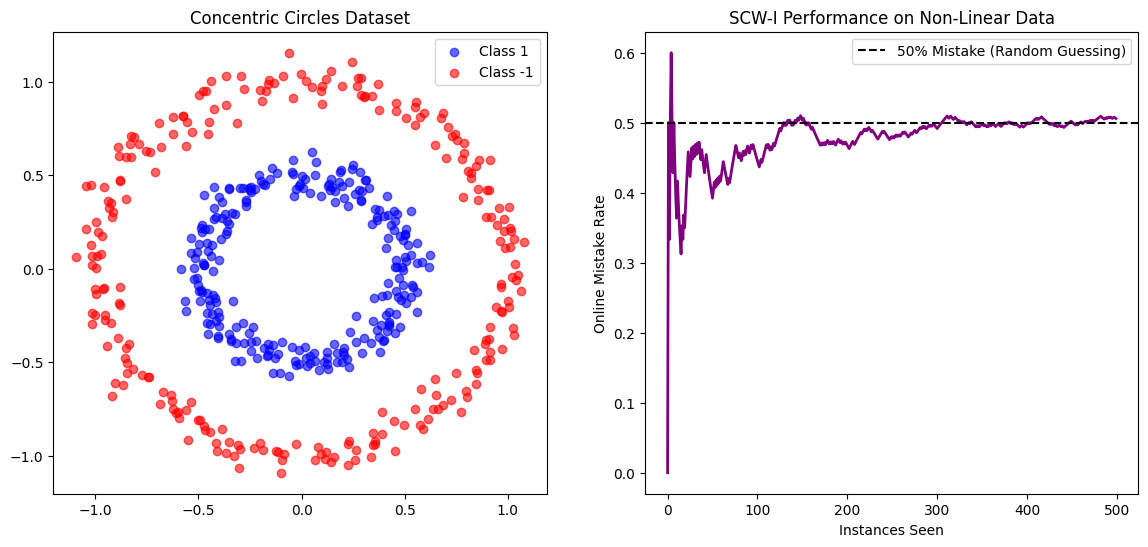

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm
from sklearn.datasets import make_circles

# Re-define SCW-I
class SCW1:
    def __init__(self, n_features, C=1.0, eta=0.9):
        self.C = C
        self.eta = eta
        self.phi = norm.ppf(eta)
        self.psi = 1 + (self.phi ** 2) / 2
        self.zeta = 1 + self.phi ** 2
        self.mu = np.zeros(n_features)
        self.Sigma = np.eye(n_features)
        
    def predict(self, x):
        return np.sign(np.dot(self.mu, x))
        
    def update(self, x, y):
        m_t = y * np.dot(self.mu, x)
        v_t = np.dot(x, np.dot(self.Sigma, x))
        loss = max(0, self.phi * np.sqrt(v_t) - m_t)
        if loss > 0:
            alpha_t = min(self.C, max(0, (1 / (v_t * self.zeta)) * (-m_t * self.psi + np.sqrt( (m_t**2 * self.phi**4)/4 + v_t * self.phi**2 * self.zeta ))))
            u_t = 0.25 * (-alpha_t * v_t * self.phi + np.sqrt( (alpha_t * v_t * self.phi)**2 + 4 * v_t ))**2
            if u_t < 0: return
            beta_t = (alpha_t * self.phi) / (np.sqrt(u_t) + v_t * alpha_t * self.phi) if (np.sqrt(u_t) + v_t * alpha_t * self.phi) != 0 else 0
            Sigma_x = np.dot(self.Sigma, x)
            self.mu = self.mu + alpha_t * y * Sigma_x
            self.Sigma = self.Sigma - beta_t * np.outer(Sigma_x, Sigma_x)

# Generate concentric circles data
X_fail, y_fail = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
y_fail = np.where(y_fail == 0, -1, 1)

# Train online
model_fail = SCW1(n_features=X_fail.shape[1], C=1.0, eta=0.9)
mistakes = 0
mistake_rates = []
for i in range(len(X_fail)):
    y_pred = model_fail.predict(X_fail[i])
    if y_pred == 0: y_pred = 1
    if y_pred != y_fail[i]:
        mistakes += 1
    model_fail.update(X_fail[i], y_fail[i])
    mistake_rates.append(mistakes / (i + 1))

# Visualization
os.makedirs("results", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Dataset distribution
ax1.scatter(X_fail[y_fail==1, 0], X_fail[y_fail==1, 1], label="Class 1", color='blue', alpha=0.6)
ax1.scatter(X_fail[y_fail==-1, 0], X_fail[y_fail==-1, 1], label="Class -1", color='red', alpha=0.6)
ax1.set_title("Concentric Circles Dataset")
ax1.legend()

# Plot 2: Mistake Rate over time showing it converges to ~50% random guessing
ax2.plot(mistake_rates, color='purple', linewidth=2)
ax2.axhline(y=0.5, color='black', linestyle='--', label='50% Mistake (Random Guessing)')
ax2.set_xlabel('Instances Seen')
ax2.set_ylabel('Online Mistake Rate')
ax2.set_title('SCW-I Performance on Non-Linear Data')
ax2.legend()

plt.savefig('results/failure_mode.png')
plt.show()


## Explanation of Failure

The method fails dramatically in this scenario because the model's online average mistake rate permanently converges around $50\%$, which implies strictly random guessing on an otherwise perfectly separable pattern. This confirms the critical limitation attached to *Assumption 3 (from Task 1.2)*, which assumed that classes are separated by a geometrically linear boundary. The SCW updates ($\mu_{t+1} = \mu_t + \alpha_t y_t \Sigma_t x_t$) only adjust a flat multi-dimensional axis in weight space; when data points of Class 1 fully surround points from Class -1 on all axes concurrently, any global continuous linear split must bisect the inner cluster, ruining exactly half of the points.

## Concrete Modification

This failure mode can be addressed by extending the linear SCW method into a non-linear variant via the *kernel trick* (as stated in Lemma 1 of the paper), projecting the raw input space features $\vec{x}$ into a higher-dimensional implicit space using a transformation like a Radial Basis Function (RBF) kernel before passing them to the SCW updates.